# Nijlpaarden van Escobar

## Modelleren van de groei van de populatie

In [1]:
# nodige modules importeren
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# nijlpaarden worden maximaal 45 jaar
leeftijden = np.arange(46)
print(leeftijden)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]


In [3]:
# bevolkingsmatrix met aantallen per leeftijd
# begin aantal nijlpaarden te tellen vanaf het jaar 1994, dan zijn er 4 (3 vrouwtjes en 1 mannetje)
# jaar 0 is 1994 - nijlpaarden zijn dan 23 jaar oud
n0F = np.zeros(46)  # bevolkingsmatrix vrouwtjes van 0 t.e.m. 46 jaar, ze worden max. 45 jaar
n0M = np.zeros(46)  # bevolkingsmatrix mannetjes van 0 t.e.m. 46 jaar, ze worden max. 45 jaar
n0F[22] = 3         # aantal vrouwtjes van 23 jaar
n0M[22] = 1         # aantal mannetjes van 23 jaar
print(n0F)
print(n0M)
print(np.shape(n0F))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(46,)


In [4]:
# age = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]
# fecundity = np.ones((0,45))*[0.0, 0.0, 0.0, 0.009, 0.06, 0.25, 0.44, 0.491, 0.499, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.495, 0.49, 0.485, 0.48, 0.475, 0.47, 0.465, 0.46, 0.455, 0.45, 0.445, 0.44, 0.435, 0.43, 0.425, 0.42, 0.415, 0.41, 0.405, 0.4]
# vruchtbaarheid
# worden vruchtbaar vanaf leeftijd van 3 jaar - bij optimale vruchtbaarheid 1 kalf op 2 jaar
# cijfers uit wetenschapelijke paper
# wordt eerste rij in vierkante matrix - migratiematrix (migratie van leeftijd) - Lesliematrix 
fecundity = np.array([[0.0, 0.0, 0.0, 0.009, 0.06, 0.25, 0.44, 0.491, 0.499, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.495, 0.49, 0.485, 0.48, 0.475, 0.47, 0.465, 0.46, 0.455, 0.45, 0.445, 0.44, 0.435, 0.43, 0.425, 0.42, 0.415, 0.41, 0.405, 0.4]])

# overlevingscijfers
# bv. van de 0-jarigen wordt 88 % 1 jaar, van de 45-jarigen wordt 0 % 46 jaar
female_survival = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.880, 0.859, 
                  0.834, 0.806, 0.772, 0.732, 0.686, 0.0]  # -> nog naar diagonaalmatrix
male_survival = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969,
                 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 
                 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]  # -> nog naar diagonaalmatrix

print(fecundity)
print(female_survival)
print(male_survival)

print(np.shape(fecundity))
print(np.shape(female_survival))
print(np.shape(male_survival))

[[0.    0.    0.    0.009 0.06  0.25  0.44  0.491 0.499 0.5   0.5   0.5
  0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5   0.5
  0.5   0.5   0.495 0.49  0.485 0.48  0.475 0.47  0.465 0.46  0.455 0.45
  0.445 0.44  0.435 0.43  0.425 0.42  0.415 0.41  0.405 0.4  ]]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.88, 0.859, 0.834, 0.806, 0.772, 0.732, 0.686, 0.0]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]
(1, 46)
(46,)
(46,)


In [5]:
# Lesliematrix vrouwtjes: F
F_onderstedeel = np.identity(46) * female_survival
print(F_onderstedeel)
print(np.shape(F_onderstedeel))

[[0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 [0.    0.    0.97  ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(46, 46)


In [6]:
F = np.concatenate((fecundity,F_onderstedeel))
print(F)
print(np.shape(F))

[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(47, 46)


In [7]:
# laatste rij wegdoen
F = F[0:46,]
print(F)
print(np.shape(F))

[[0.    0.    0.    ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]]
(46, 46)


In [8]:
# Lesliematrix mannetjes: M
M_onderstedeel = np.identity(46) * male_survival
print(M_onderstedeel)
print(np.shape(M_onderstedeel))

[[0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 [0.    0.    0.97  ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.704 0.    0.   ]
 [0.    0.    0.    ... 0.    0.653 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(46, 46)


In [9]:
# mannetjes baren niet
rij1_M = np.zeros((1, 46))
print(rij1_M)
print(np.shape(rij1_M))

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(1, 46)


In [10]:
M = np.concatenate((rij1_M, M_onderstedeel))
print(M)
print(np.shape(M))

[[0.    0.    0.    ... 0.    0.    0.   ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.704 0.    0.   ]
 [0.    0.    0.    ... 0.    0.653 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(47, 46)


In [11]:
# laatste rij wegdoen
M = M[0:46,]
print(M)
print(np.shape(M))

[[0.    0.    0.    ... 0.    0.    0.   ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.704 0.    0.   ]
 [0.    0.    0.    ... 0.    0.653 0.   ]]
(46, 46)


De Lesliematrices hebben als dimensie 46 x 46. Ze kunnen vermenigvuldigd worden met een kolommatrix van dimensie 46 x 1, wat dus de dimensie van de bevolkingsmatrix moet zijn. Dit klopt voor n0F en n0M. 

In [12]:
# na 1 jaar, dus in 1995
# matrixvermenigvuldiging met functie dot() die de betreffende matrices als parameters meekrijgt; dot(A, B) 
n1F = np.dot(F, n0F)
print(n1F)
n1M = np.dot(M, n0M)
print(n1M)
# nu zitten alle kalfjes bij de vrouwtjes, echter bij kalfjes evenveel vrouwtjes als mannetjes
nkids = n1F[0]/2  
n1F[0] = nkids
print(n1F)
n1M[0] = nkids
print(n1M)

# aantal nijlpaarden
aantal_nijlpaarden = np.sum(n1F) + np.sum(n1M)  
print("aantal_nijlpaarden:", aantal_nijlpaarden)

[1.5   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    2.916
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.969
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
[0.75  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    2.916
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
[0.75  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.969
 0.    0.    0.    0.    0.    0

In [13]:
# na 2 jaar, dus in 1996
n2F = np.dot(F, n1F)
print(n2F)
n2M = np.dot(M, n1M)
print(n2M)
# nu zitten alle kalfjes bij de vrouwtjes, echter bij kalfjes evenveel vrouwtjes als mannetjes
nkids = n2F[0]/2  
n2F[0] = nkids
print(n2F)
n2M[0] = nkids
print(n2M)

# aantal nijlpaarden
aantal_nijlpaarden = np.sum(n2F) + np.sum(n2M)  
print("aantal_nijlpaarden:", aantal_nijlpaarden)

[1.458    0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 2.834352 0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.      ]
[0.       0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.938961 0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.      ]
[0.729    0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 2.834352 0.     

In [14]:
# na 3 jaar, dus in 1997
n3F = np.dot(F, n2F)
print(n2F)
n3M = np.dot(M, n2M)
print(n3M)
# nu zitten alle kalfjes bij de vrouwtjes, echter bij kalfjes evenveel vrouwtjes als mannetjes
nkids = n3F[0]/2  
n3F[0] = nkids
print(n3F)
n3M[0] = nkids
print(n3M)

# aantal nijlpaarden
aantal_nijlpaarden = np.sum(n3F) + np.sum(n3M)  
print("aantal_nijlpaarden:", aantal_nijlpaarden)

[0.729    0.66     0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 2.834352 0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.      ]
[0.         0.64152    0.6204     0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.90985321 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[0.708588   0.64152    0.6204     0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.       

In [15]:
# evolutie over 41 jaar, dus van 1994 tot 2035
# t.e.m. 2004 is 10 jaar
# aantal jaren vanaf 1994 t.e.m 2004 is 11 verschillende jaren
njaar = 41

# matrix maken met bevolkingsmatrices van de vrouwtjes kolom per kolom naast elkaar
nF = np.zeros((46, njaar+1))  # matrix aanmaken met de juiste dimensie (46x41)
nF[:,0] = n0F   # eerste kolom invullen met aantallen van jaar 1994
print(nF)
print(np.shape(nF))

# idem voor de mannetjes
nM = np.zeros((46, njaar+1))
nM[:,0] = n0M
print(nM)
print(np.shape(nM))

# matrices maken die de evolutie van de totale bevolkingsaantallen weergeeft
totF = np.zeros(njaar+1)      # rijmatrix aanmaken met de juiste dimensie  42 = njaar+1
print(np.shape(totF))
totM = np.zeros(njaar+1)
tot = np.zeros(njaar+1)
totF[0] = np.sum(n0F)    # aantal vrouwtjes bepalen in jaar 1994
totM[0] = np.sum(n0M)
tot[0] = totF[0] + totM[0]
print(totF) 
print(totM)
print(tot)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 42)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 42)
(42,)
[3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [16]:
# evolutie over 41 jaar, dus van 1994 tot 2035
# 1994
print(1994, tot[0])               # jaar = 0 komt overeen met jaartal 1994

# latere jaren
nFtemp = n0F
nMtemp = n0M
for jaar in range(1, njaar+1):     # jaar = 1 komt overeen met jaartal 1995
    nFtemp = np.dot(F,nFtemp)
    nMtemp = np.dot(M,nMtemp)
    nkids = nFtemp[0]
    nFtemp[0] = nkids/2
    nMtemp[0] = nkids/2  
    nF[:,jaar] = nFtemp
    nM[:,jaar] = nMtemp
    totF[jaar] = np.sum(nFtemp)
    totM[jaar] = np.sum(nMtemp)
    tot[jaar] = totF[jaar] + totM[jaar] 
    print(jaar+1994, totF[jaar], totM[jaar], tot[jaar])

1994 4.0
1995 3.666 1.7189999999999999 5.385
1996 4.223352 2.327961 6.551313
1997 4.7254981439999995 2.880361209 7.605859353
1998 5.194972195968 3.3987695355209997 8.593741731489
1999 5.629260754430976 3.8807068251979286 9.509967579628904
2000 6.045360446342456 4.343203077091006 10.388563523433461
2001 6.4961654014895664 4.839184939991375 11.335350341480941
2002 7.024338253698269 5.411346734992403 12.43568498869067
2003 7.617247822117059 6.054375812441014 13.671623634558074
2004 8.262040922795675 6.757126751219758 15.019167674015433
2005 8.947502257109248 7.508232361231679 16.455734618340927
2006 9.666780014835865 8.299693063465208 17.96647307830107
2007 10.41696221594807 9.130650782230099 19.547612998178167
2008 11.20679556947322 10.006599590993405 21.213395160466625
2009 12.044296180563732 10.937786755525227 22.982082936088958
2010 12.938447867051973 11.93351290673247 24.871960773784444
2011 13.901287407262974 13.001927249203357 26.903214656466332
2012 14.941044439188985 14.151140280

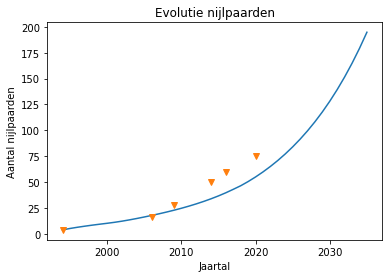

194.69706433627556

In [17]:
year = range(1994,1994+njaar+1)
yearS = [1994, 2006, 2009, 2014, 2016, 2020]
totS = [4, 16, 28, 50, 60, 75]

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.plot(year, tot)  
plt.plot(yearS, totS, "v")
# plt.scatter(yearS, totS, "v")
plt.show()

totF[41]+totM[41]

Beetje te conservatief. Het gaat blijkbaar sneller. 

## Model blijkt te conservatief 

### Exponentiele groei

Groeifactor schatten

In [18]:
4**(1/12)

1.122462048309373

In [19]:
(7/4)**(1/3)

1.205071132087615

In [20]:
(25/14)**(1/5)

1.1229551070568211

In [21]:
(6/5)**(1/2)

1.0954451150103321

In [22]:
(5/4)**(1/4)

1.057371263440564

In [23]:
(75/4)**(1/26)

1.1193388754569054

In [24]:
(65/4)**(1/26)

1.1131950929980778

Op basis van deze berekeningen kan je de groeifactor schatten. Bv. ergens tussen 10 en 13 %.

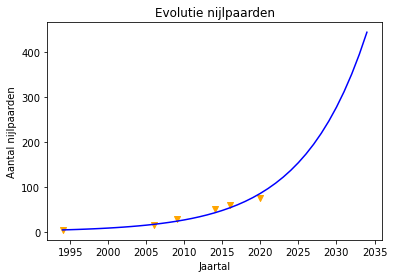

In [25]:
x = np.arange(1994,2035)
y = 4*1.125**(x-1994)

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(yearS, totS, marker ="v", color="orange")
plt.plot(x, y, color="blue")

plt.show()

Maar je kan ook regressie uitvoeren m.b.v. Python.<br>
Je zorgt er eerst voor dat de nodige functies beschikbaar zijn (zie ook notebooks over regressie van Python in de wiskundeles en de notebook over exponentiele regressie uit Epidemie van Python in STEM).

In [26]:
# expreg 
from scipy.optimize import curve_fit

def exp(x, a, b):
    """Voorschrift exponentiële functie."""
    return b * a**x 

def expreg(x, y):
    """Best passende kromme bepalen."""
    popt, pcov = curve_fit(exp, x, y)         # curve_fit kijkt in def exp hoe die functie eruit ziet
    # curve_fit geeft twee zaken terug, waaraan gerefereerd wordt met popt en pcov
    # enkel eerste nodig, die a en b van gezochte exponentiële functie geeft
    a =  popt[0]
    b =  popt[1]
    print("y =", b, "*", a, "**x voor periode", x)      # toon voorschrift
    return a, b                                 # geeft parameters terug uit vergelijking exponentiële functie


In [27]:
# data populatie
yearS = [1994, 2006, 2009, 2014, 2016, 2020, 2021]
totS = [4, 16, 28, 50, 60, 75, 110]

In [28]:
# de grote getallen in yearS leveren problemen op bij het gebruik van de functies
# die getallen verkleinen door overal 1994 van af te trekken
x1 = [0, 12, 15, 20, 22, 26, 27]
a1, b1 = expreg(x1, totS)
y1_regressielijn = exp(x1, a1, b1) 

y = 5.108471198910703 * 1.116405957100146 **x voor periode [0, 12, 15, 20, 22, 26, 27]


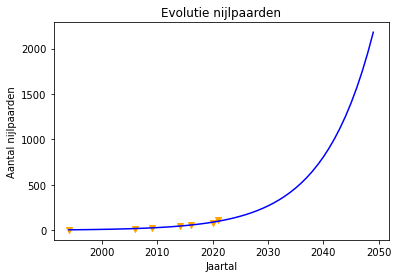

In [29]:
x = np.arange(1994,2050)
y = exp(x-1994, a1, b1)  # de grafiek van de regressielijn moet 1994 eenheden opschuiven naar rechts

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.scatter(yearS, totS, marker ="v", color="orange")
plt.plot(x, y, color="blue")

plt.show()


## Aanpassingen doen aan de vruchtbaarheidscijfers

1 kalf per 1,5 jaar i.p.v. per 2 jaar. En een jaar vroeger vruchtbaar.

In [30]:
# aangepast

# vruchtbaarheid
# worden vruchtbaar vanaf leeftijd van 2 jaar - bij optimale vruchtbaarheid 1 kalf op 1,5 jaar

# wordt eerste rij in vierkante matrix - migratiematrix (migratie van leeftijd) - Lesliematrix 
fecundity = np.array([[0.0, 0.0, 0.009, 0.06, 0.06, 0.25, 0.44, 0.491, 0.499, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.667, 0.495, 0.49, 0.485, 0.48, 0.475, 0.47, 0.465, 0.46, 0.455, 0.45, 0.445, 0.44, 0.435, 0.43, 0.425, 0.42, 0.415, 0.41, 0.405, 0.4]])

# overlevingscijfers
# bv. van de 0-jarigen wordt 88 % 1 jaar, van de 45-jarigen wordt 0 % 46 jaar
female_survival = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 
                   0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.880, 0.859, 
                  0.834, 0.806, 0.772, 0.732, 0.686, 0.0]  # -> nog naar diagonaalmatrix
male_survival = [0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 
                 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969,
                 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 
                 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]  # -> nog naar diagonaalmatrix

print(fecundity)
print(female_survival)
print(male_survival)

print(np.shape(fecundity))
print(np.shape(female_survival))
print(np.shape(male_survival))

[[0.    0.    0.009 0.06  0.06  0.25  0.44  0.491 0.499 0.667 0.667 0.667
  0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667 0.667
  0.667 0.667 0.495 0.49  0.485 0.48  0.475 0.47  0.465 0.46  0.455 0.45
  0.445 0.44  0.435 0.43  0.425 0.42  0.415 0.41  0.405 0.4  ]]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.972, 0.967, 0.961, 0.954, 0.946, 0.936, 0.926, 0.913, 0.897, 0.88, 0.859, 0.834, 0.806, 0.772, 0.732, 0.686, 0.0]
[0.88, 0.94, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.969, 0.963, 0.957, 0.949, 0.94, 0.93, 0.918, 0.904, 0.887, 0.867, 0.844, 0.817, 0.785, 0.748, 0.704, 0.653, 0.0]
(1, 46)
(46,)
(46,)


In [31]:
# aangepast
F2 = np.concatenate((fecundity,F_onderstedeel))
print(F2)
print(np.shape(F2))
F2 = F2[0:46,]
print(F2)
print(np.shape(F2))

[[0.    0.    0.009 ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]
(47, 46)
[[0.    0.    0.009 ... 0.41  0.405 0.4  ]
 [0.88  0.    0.    ... 0.    0.    0.   ]
 [0.    0.94  0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.732 0.    0.   ]
 [0.    0.    0.    ... 0.    0.686 0.   ]]
(46, 46)


In [32]:
# aangepast
# evolutie over 41 jaar, dus van 1994 tot 2035
njaar = 41
# 1994
print(1994, tot[0])               # jaar = 0 komt overeen met jaartal 1994

# latere jaren
nFtemp = n0F
nMtemp = n0M
for jaar in range(1, njaar+1):     # jaar = 1 komt overeen met jaartal 1995
    nFtemp = np.dot(F2,nFtemp)
    nMtemp = np.dot(M,nMtemp)
    nkids = nFtemp[0]
    nFtemp[0] = nkids/2
    nMtemp[0] = nkids/2  
    nF[:,jaar] = nFtemp
    nM[:,jaar] = nMtemp
    totF[jaar] = np.sum(nFtemp)
    totM[jaar] = np.sum(nMtemp)
    tot[jaar] = totF[jaar] + totM[jaar] 
    print(jaar+1994, totF[jaar], totM[jaar], tot[jaar])

1994 4.0
1995 3.9165 1.9695 5.886
1996 4.687278 2.791887 7.479165
1997 5.383647816 3.5385108809999997 8.922158697
1998 6.039415130351999 4.243212469905 10.282627600257
1999 6.446078912440896 4.697524983207849 11.143603895648745
2000 6.8593976807622905 5.157240311510841 12.016637992273132
2001 7.335362852431066 5.678382390932876 13.013745243363942
2002 7.9239494780427915 6.3109579593369265 14.234907437379718
2003 8.607753119815666 7.044881110139619 15.652634229955286
2004 9.372253620335865 7.867339448759947 17.23959306909581
2005 10.246883594166157 8.807613698288588 19.054497292454744
2006 11.203194063643146 9.835619905423531 21.038813969066677
2007 12.233287034207894 10.945556366938913 23.178843401146807
2008 13.347326303627565 12.144374172130071 25.491700475757636
2009 14.544644480726046 13.433667433202118 27.978311913928163
2010 15.839178417072468 14.82811911916966 30.667297536242128
2011 17.25387150519802 16.346773289110377 33.600644794308394
2012 18.81172111722193 18.01246271232423

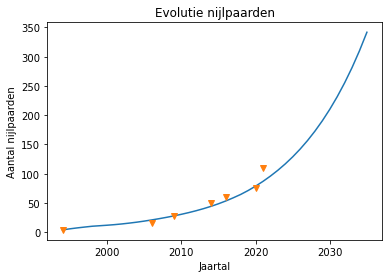

In [33]:
# aangepast
year = range(1994,1994+njaar+1)
yearS = [1994, 2006, 2009, 2014, 2016, 2020, 2021]
totS = [4, 16, 28, 50, 60, 75, 110]

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.plot(year,tot) 
plt.plot(yearS,totS,"v")
plt.show()

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 77)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(46, 77)
(77,)
[3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
[4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

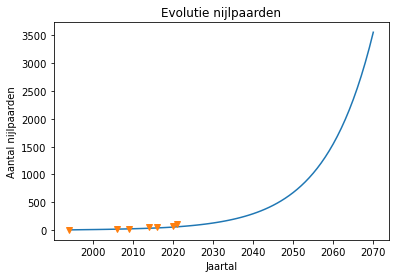

In [34]:
# wat in 2070?
# evolutie over 41+35 jaar, dus van 1994 tot 2070
njaar = 76

# matrix maken met bevolkingsmatrices van de vrouwtjes kolom per kolom naast elkaar
nF = np.zeros((46, njaar+1))  # matrix aanmaken met de juiste dimensie (46x41)
nF[:,0] = n0F   # eerste kolom invullen met aantallen van jaar 1994
print(nF)
print(np.shape(nF))

# idem voor de mannetjes
nM = np.zeros((46, njaar+1))
nM[:,0] = n0M
print(nM)
print(np.shape(nM))

# matrices maken die de evolutie van de totale bevolkingsaantallen weergeeft
totF = np.zeros(njaar+1)      # rijmatrix aanmaken met de juiste dimensie
print(np.shape(totF))
totM = np.zeros(njaar+1)
tot2 = np.zeros(njaar+1)
totF[0] = np.sum(n0F)    # aantal vrouwtjes bepalen in jaar 1994
totM[0] = np.sum(n0M)
tot2[0] = totF[0] + totM[0]
print(totF) 
print(totM)
print(tot2)


# 1994
print(1994, tot[0])               # jaar = 0 komt overeen met jaartal 1994

# latere jaren
nFtemp = n0F
nMtemp = n0M
for jaar in range(1, njaar+1):     # jaar = 1 komt overeen met jaartal 1995
    nFtemp = np.dot(F,nFtemp)
    nMtemp = np.dot(M,nMtemp)
    nkids = nFtemp[0]
    nFtemp[0] = nkids/2
    nMtemp[0] = nkids/2  
    nF[:,jaar] = nFtemp
    nM[:,jaar] = nMtemp
    totF[jaar] = np.sum(nFtemp)
    totM[jaar] = np.sum(nMtemp)
    tot2[jaar] = totF[jaar] + totM[jaar] 
    print(jaar+1994, tot2[jaar])

year = range(1994,1994+njaar+1)
yearS = [1994, 2006, 2009, 2014, 2016, 2020, 2021]
totS = [4, 16, 28, 50, 60, 75, 110]

plt.title("Evolutie nijlpaarden") 
plt.xlabel("Jaartal") 
plt.ylabel("Aantal nijlpaarden") 
plt.plot(year,tot2) 
plt.plot(yearS,totS,"v")
plt.show()